### Bias analysis with finite sampling, Chrom X
Let's do the same for chrom X. The only differences ara that we need to use a different simulator, and a differnt sampling scheme. We sample one copy from males and two copies from females. 

Because of this, the $n_1$ and $n_2$ in Hudson's FST need to be adjusted accordingly. 

In [1]:
require(doParallel)

Loading required package: doParallel
Loading required package: foreach
Loading required package: iterators
Loading required package: parallel


In [2]:
sim_multi_X<-function(Nm=c(100, 100), Nf=c(100, 100), 
            Mm=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), Mf=matrix(c(0.95, 0.05, 0.05, 0.95), nc=2), 
            L=500, t=10)
{
    # INITIALISATION
    # EMPTY MATRICES. pop1m = ALLELE FREQ OF MALES IN POP1. COLUMNS = TIME. ROWS = LOCI
    pop1m<-matrix(NA, nr=L, nc=t+1)
    pop1f<-matrix(NA, nr=L, nc=t+1)
    pop2m<-matrix(NA, nr=L, nc=t+1)
    pop2f<-matrix(NA, nr=L, nc=t+1)
    # INITIAL FREQ, ALL AROUND 0.5?
    pop1m[,1]<-runif(L, 0.4, 0.6)
    pop1f[,1]<-pop1m[,1]
    pop2m[,1]<-pop1m[,1]
    pop2f[,1]<-pop1m[,1]
    # PROPAGATION
    for (i in 1:t)
    {
        # NEW GAMETE POOL FREQ FOR THE DIFFERENT COMPARTMENTS, AFTER MIGRATION
        gametem<-Mm%*%rbind(pop1m[,i], pop2m[,i])
        gametef<-Mf%*%rbind(pop1f[,i], pop2f[,i])
        # SAMPLING OFFSPRING
        pop1m[,i+1]<-rbinom(L, size=Nm[1], prob=gametef[1,])/Nm[1]
        pop1f[,i+1]<-(rbinom(L, size=Nf[1], prob=gametem[1,])+rbinom(L, size=Nf[1], prob=gametef[1,]))/(2*Nf[1])
        pop2m[,i+1]<-rbinom(L, size=Nm[2], prob=gametef[2,])/Nm[2]
        pop2f[,i+1]<-(rbinom(L, size=Nf[2], prob=gametem[2,])+rbinom(L, size=Nf[2], prob=gametef[2,]))/(2*Nf[2])
    }
    return(list(pop1m=pop1m, pop1f=pop1f, pop2m=pop2m, pop2f=pop2f))
}
#
cal_nei_fst<-function(p1, p2)
{
    p<-(p1+p2)/2
    return(mean((p1-p2)^2/(2*p*(1-p)), na.rm=T))
}
#
cal_hudson_fst<-function(p1, p2, n1, n2)
{
    temp1<-(p1-p2)^2-p1*(1-p1)/(n1-1)-p2*(1-p2)/(n2-1)
    temp2<-p1*(1-p2)+p2*(1-p1)
    return(mean(temp1/temp2, na.rm=T))
}

### 1. Sim the true population, get the true allele frequency, true (Nei = raw) FST

In [3]:
# THE TRUE PARAMETERS
L<-500
Nm<-c(1000, 1000)
Nf<-c(1000, 1000)
m<-0.01
Mm<-matrix(c(1-m, m, m, 1-m), nc=2)
Mf<-matrix(c(1-m, m, m, 1-m), nc=2)
t<-60
# SIM THE POPULATION
dat<-sim_multi_X(Nm=Nm, Nf=Nf, Mm=Mm, Mf=Mf, L=L, t=t)
# p1 AND p2 FROM THE FINAL GENERATION. WEIGHTED AVERAGE
p1m<-dat$pop1m[,t+1]
p1f<-dat$pop1f[,t+1]
p2m<-dat$pop2m[,t+1]
p2f<-dat$pop2f[,t+1]
p1<-(p1m+2*p1f)/3
p2<-(p2m+2*p2f)/3
# POPULATION TRUE FST
true_FST<-cal_nei_fst(p1, p2)
true_FST

[1] 0.00713828

### 2. From this true population, add sampling, get observed allele frequency, calculate Nei and Hudson's FST
The <code>n</code> below is defined as the sample size per sex per population, meaning we are sampling <code>n</code> males and females per population, and <code>3n</code> copies of alleles per population. As a result, <code>3n</code> is used in the Hudson's formula. 

In [4]:
# AN ARRAY OF SAMPLE SIZES (MOSQUITOES PER SEX PER POPULATION)
n<-seq(10, 150, 10)
length(n)
times<-500
# EMPTY VECTORS FOR AVERAGE FST
nei_FST<-rep(NA, length(n))
hudson_FST<-rep(NA, length(n))
# LET'S LOOK AT THE VARIANCE AS WELL
var_nei_FST<-rep(NA, length(n))
var_hudson_FST<-rep(NA, length(n))
#
cl<-makeCluster(6)
registerDoParallel(cl)
#
for (i in 1:length(n))
{
    temp<-foreach(j=1:times, .combine='rbind') %dopar%
    {
        # GET THE OBSERVED FREQ (ADD BINOMIAL SAMPLING). 
        # ONE COPY FROM MALES, TWO COPIES FROM FEMALES
        x1<-(rbinom(L, size=n[i], prob=p1m)+rbinom(L, size=2*n[i], prob=p1f))/(3*n[i])
        x2<-(rbinom(L, size=n[i], prob=p2m)+rbinom(L, size=2*n[i], prob=p2f))/(3*n[i])
        # THE TWO FST ESTIMATORS
        return(c(cal_nei_fst(x1, x2), cal_hudson_fst(x1, x2, 3*n[i], 3*n[i])))
    }
    # FOR EACH n GET THE AVERAGE FROM 500 SIMS
    nei_FST[i]<-mean(temp[,1], na.rm=T)
    hudson_FST[i]<-mean(temp[,2], na.rm=T)
    # GET THE VARIANCE
    var_nei_FST[i]<-var(temp[,1], na.rm=T)
    var_hudson_FST[i]<-var(temp[,2], na.rm=T)
}
stopCluster(cl)

[1] 15

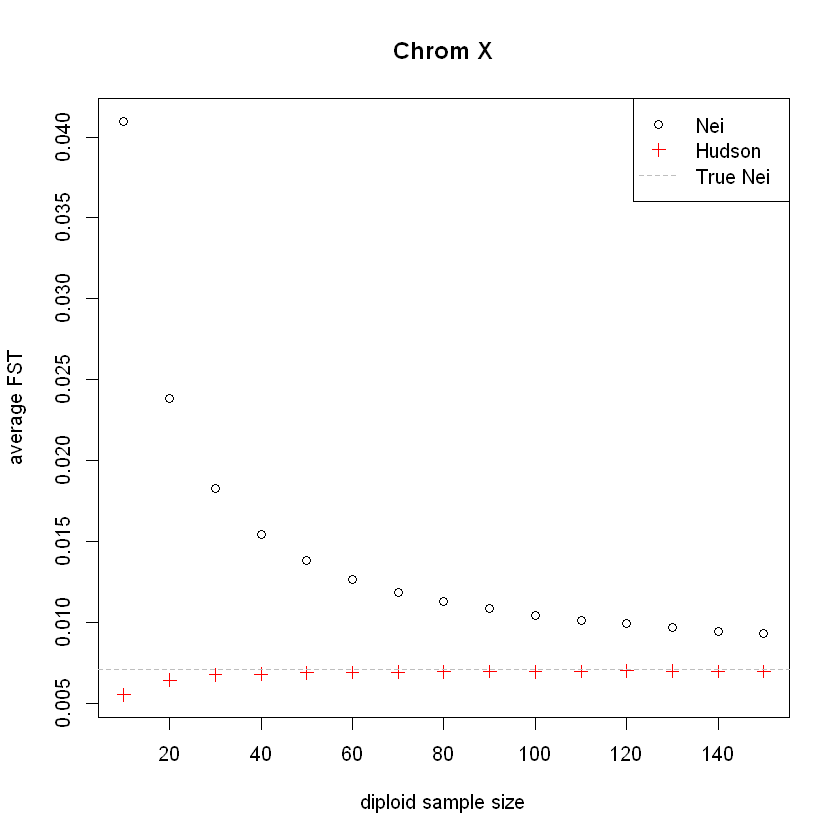

In [5]:
plot(n, nei_FST, ylim=c(min(nei_FST, hudson_FST), max(nei_FST, hudson_FST)), 
    ylab='average FST', xlab='diploid sample size', main='Chrom X')
points(n, hudson_FST, col='red', pch=3)
abline(h=true_FST, col='grey', lty=2)
legend('topright', legend=c('Nei', 'Hudson', 'True Nei'), col=c(1, 2, 'grey'), lty=c(NA, NA, 2), pch=c(1, 3, NA))